In [72]:
# Import necessary libraries
import math
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.wcs import WCS
from astropy.table import Table, Column
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.modeling import models, fitting
from astropy.visualization import ZScaleInterval
from photutils.detection import DAOStarFinder, find_peaks
from photutils.aperture import CircularAperture, CircularAnnulus, CircularAnnulus, ApertureStats, aperture_photometry
from acstools import acszpt
from stdpipe import plots
from astroquery.vizier import Vizier
from matplotlib.colors import LogNorm
from astroquery.gaia import Gaia

In [2]:
plt.rc('image', origin='lower', cmap='gray')

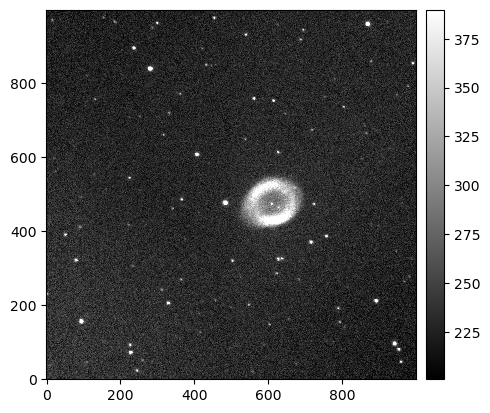

In [3]:
# Open FITS file
fits_file = fits.open('/home/islam/M57/Reduced/V_20240419_0054.fits')
image_data = fits_file[0].data

# Display the full image
plt.figure()
plots.imshow(image_data, [0.5, 99.7], interpolation='nearest')
plt.show()

In [4]:
image_header = fits_file[0].header
image_header

SIMPLE  =                    T / Standard FITS file                             
BITPIX  =                  -32 / ASCII or bytes array                           
NAXIS   =                    2 / Minimal header                                 
NAXIS1  =                 1000                                                  
NAXIS2  =                 1000                                                  
EXTEND  =                    T / There may be FITS ext                          
OBSERVER= 'CU Students'                                                         
NOTES   = ''                                                                    
DATE_OBS= '2024-04-20'         / Date of observation                            
UT      = '01:17:14.510772'    / Time of Observation                            
EXPTIME = '60.0    '           / Exposure time in seconds                       
CCD_TEMP= '-119.7  '           / Camera temperature                             
FOCUS   = '146988  '        

In [8]:
# Calculate background statistics
mean, median, std = sigma_clipped_stats(image_data, sigma=3.0)

# Detect stars
daofind = DAOStarFinder(fwhm=3.0, threshold=5.0 * std)
sources = daofind(image_data - median)
sources

id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag
int64,float64,float64,float64,float32,float64,int64,float32,float32,float32,float32
1,44.63003187296476,14.444606460974377,0.426111263182794,0.61554915,-0.17532645428118662,25,45.78923,367.49506,-6.413129,-0.0922208
2,246.64073639665796,22.77461384959169,0.43880399233140277,0.1505342,0.19433388678611488,25,200.68349,3294.203,-8.794375,-0.5375243
3,959.7086019830103,46.08395621559794,0.4743987792100061,-0.39816824,-0.1720037327885669,25,285.68884,3957.475,-8.993546,-1.0459911
4,260.9161963891265,50.41063090000704,0.23359510207707848,0.3260073,0.02050958728022679,25,86.44591,1399.5507,-7.8649716,-0.08359298
5,229.5393867586326,71.36493499071219,0.37324446072429945,0.44132242,0.0033736462128284893,25,634.9904,10459.735,-10.048801,-1.7784225
6,953.9506324422093,80.12254652931331,0.45085572460601314,-0.28204852,-0.05485123620304938,25,549.5547,8067.7734,-9.766885,-1.6916213
7,227.94976177641644,91.31934847807362,0.33069932021825027,0.35269758,-0.10442077373355851,25,268.92987,4516.0205,-9.136889,-0.86099756
8,942.2934257112054,95.22400308026583,0.4297370029694654,-0.20091219,-0.12224121548610516,25,1400.5483,21183.842,-10.815011,-2.7099814
9,604.5368519205535,147.20573006981616,0.6111530108830725,0.527536,-0.07369985994288247,25,130.06377,1717.1887,-8.087045,-0.0148894265


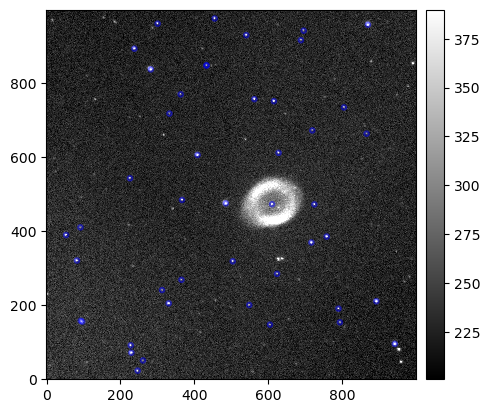

In [48]:
# Display detected stars
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
apertures = CircularAperture(positions, r=6.0)
plt.figure()
plots.imshow(image_data, [0.5, 99.7], interpolation='nearest')
apertures.plot(color='blue', lw=1.5, alpha=0.5)
plt.show()

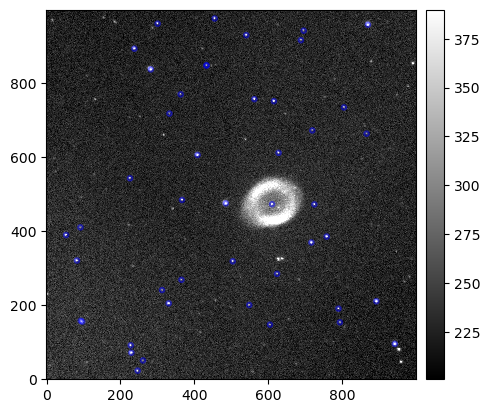

In [49]:
# Create a mask to exclude bright regions

mask = np.zeros(image_data.shape, dtype=bool)
mask[0:30, 0:50] = True
mask[300:400, 600:700] = True
mask[0:1000, 950:1000] = True
#mask[200:290, 300:550] = True
#mask[330:400, 400:600] = True
#mask[140:200, 400:500] = True
#mask[308:314, 477:489]= True

# Re-detect stars with the mask applied
sources = daofind(image_data - median, mask=mask)
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
apertures = CircularAperture(positions, r=6.0)
# Display the updated detection
plt.figure()
plots.imshow(image_data, [0.5, 99.7], interpolation='nearest')
apertures.plot(color='blue', lw=1.5, alpha=0.5)
plt.savefig('Stars Detected with Mask', format='png')
plt.show()

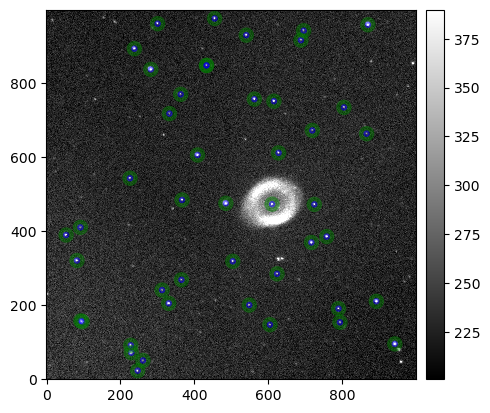

In [50]:
# Define annuli for background measurement
annulus_aperture = CircularAnnulus(positions, r_in=12, r_out=18)
aperstats = ApertureStats(image_data, annulus_aperture)

# Plot the annuli
plt.figure()
plots.imshow(image_data, [0.5, 99.7], interpolation='nearest')
apertures.plot(color='blue', lw=1.5, alpha=0.5)
annulus_aperture.plot(color='green', lw=1.5, alpha=0.5)
#plt.savefig('Annual Background', format='png')
plt.show()

# Calculate background
bkg_mean = aperstats.mean
aperture_area = apertures.area_overlap(image_data)
total_bkg = bkg_mean * aperture_area


In [51]:
# Perform aperture photometry
star_data = aperture_photometry(image_data, apertures)

# Add background data to the photometry table
star_data['total_bkg'] = total_bkg

# Display the photometry table
for col in star_data.colnames:
    star_data[col].info.format = '%.8g'
star_data.pprint()


 id  xcenter   ycenter  aperture_sum total_bkg
       pix       pix                          
--- --------- --------- ------------ ---------
  1 246.64074 22.774614     33342.22  27027.63
  2  260.9162 50.410631    29592.131 26864.223
  3 229.53939 71.364935     48495.31 27396.897
  4 227.94976 91.319348    35814.198  28054.77
  5 942.29343 95.224003    66378.541 26521.575
  6 604.53685 147.20573    29279.036 26091.518
  7 793.84901 153.58274    29939.712 25695.509
  8 96.526549 155.43308    61300.649 27461.714
  9 92.640549 157.69703    54213.327 27484.617
...       ...       ...          ...       ...
 37 282.12697 837.88536    78051.675 25972.368
 38 433.05013   848.783    30001.355 26037.495
 39  432.6142 848.46795    29965.116 26030.422
 40 237.70936 893.91177    42019.684 25601.892
 41 688.27076 916.92049    30207.984 26065.564
 42 540.42378 930.49982    32038.442 26024.761
 43 695.58726 942.60941    30386.843  25946.98
 44 869.51778 958.80322    82362.055  26357.65
 45 300.63853

In [52]:
f = []
for line in star_data:
    flux = line['aperture_sum'] - line['total_bkg']
    f.append(flux)

f

[6314.5902986974725,
 2727.9075476256403,
 21098.41322995821,
 7759.42842910127,
 39856.96607701271,
 3187.518681603964,
 4244.20340133657,
 33838.93477813195,
 26728.709801014706,
 5617.164052133699,
 4748.495926110176,
 13058.47656875839,
 26346.672776584783,
 2468.8717233676944,
 3579.2353776187265,
 4094.9349552685853,
 6121.812464330313,
 11398.678978747677,
 15500.569671248439,
 8706.311558224268,
 7757.721696620567,
 3595.074069287639,
 5486.275806188263,
 6271.390946299864,
 70644.29951153166,
 6296.235345968009,
 6135.800865827434,
 25766.73355207379,
 6620.941712701726,
 2858.9557042248307,
 4127.467832508297,
 2998.852174891814,
 3581.1330897627086,
 8035.015687953699,
 9010.582376856022,
 3663.4629613573925,
 52079.306245653555,
 3963.860122947448,
 3934.6944718361665,
 16417.791747819134,
 4142.4203287102355,
 6013.680994154271,
 4439.863428138968,
 56004.40459750458,
 7594.386843417578,
 8061.830366797665]

In [57]:
GAIN = 2.14  # Example value, in electrons/ADU
RON = 3.92

# Perform aperture photometry
star_data = aperture_photometry(image_data, apertures)

# Calculate total background per star
bkg_mean = aperstats.mean
aperture_area = apertures.area_overlap(image_data)
total_bkg = bkg_mean * aperture_area

# Compute flux and flux uncertainty
flux = star_data['aperture_sum'] - total_bkg
photon_noise = np.sqrt(flux * GAIN)  # Photon noise (convert ADU to electrons)
background_noise = np.sqrt(aperture_area * (std ** 2))  # Background noise
readout_noise = RON * np.sqrt(aperture_area)  # Readout noise
flux_uncertainty = np.sqrt(photon_noise ** 2 + background_noise ** 2 + readout_noise ** 2)

# Add flux and flux uncertainty to the table
star_data['total_bkg'] = total_bkg
star_data['flux'] = flux
star_data['flux_uncertainty'] = flux_uncertainty

In [58]:
# Calculate instrumental magnitudes and their uncertainties
extime = 60.0  # Exposure time from header
m_inst = []
m_inst_uncertainty = []

for line in star_data:
    flux_val = line['flux']
    flux_err = line['flux_uncertainty']

    # Compute magnitude
    mag = -2.5 * math.log10(flux_val / extime)
    m_inst.append(mag)

    # Compute magnitude uncertainty
    mag_err = (2.5 / np.log(10)) * (flux_err / flux_val)
    m_inst_uncertainty.append(mag_err)

# Add magnitudes and their uncertainties to the table
star_data['m_inst'] = m_inst
star_data['m_inst_uncertainty'] = m_inst_uncertainty

# Display the photometry table with errors
for col in star_data.colnames:
    star_data[col].info.format = '%.8g'
star_data.pprint(max_lines=-1, max_width=-1)

 id  xcenter   ycenter  aperture_sum total_bkg    flux   flux_uncertainty   m_inst   m_inst_uncertainty
       pix       pix                                                                                   
--- --------- --------- ------------ --------- --------- ---------------- ---------- ------------------
  1 246.64074 22.774614     33342.22  27027.63 6314.5903        176.29682 -5.0554848        0.030312631
  2  260.9162 50.410631    29592.131 26864.223 2727.9075        152.98715  -4.144196        0.060890513
  3 229.53939 71.364935     48495.31 27396.897 21098.413        250.43552 -6.3652464        0.012887553
  4 227.94976 91.319348    35814.198  28054.77 7759.4284        184.85812 -5.2791962        0.025866229
  5 942.29343 95.224003    66378.541 26521.575 39856.966         320.7199 -7.0558825       0.0087366712
  6 604.53685 147.20573    29279.036 26091.518 3187.5187        156.16862 -4.3132537         0.05319433
  7 793.84901 153.58274    29939.712 25695.509 4244.2034        

In [59]:
wcs = WCS(fits_file[0].header)

wcs

a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 283.398250505 33.0281563159 
CRPIX : 598.802947998 482.867233276 
CD1_1 CD1_2  : -0.000131448360842 5.73393406135e-06 
CD2_1 CD2_2  : -5.87418202726e-06 -0.000131518972612 
NAXIS : 1000  1000

In [60]:
# Assuming `wcs` is already defined and aligned with your image
# Extract pixel coordinates from the table
xcenter = star_data['xcenter']
ycenter = star_data['ycenter']

# Convert pixel coordinates to RA and Dec
world_coords = wcs.pixel_to_world(xcenter, ycenter)

# Extract RA and Dec from the SkyCoord object
ra_deg = world_coords.ra.deg  # RA in degrees
dec_deg = world_coords.dec.deg  # Dec in degrees

# Add RA and Dec as new columns to the table
star_data['RA_deg'] = Column(ra_deg, name='RA_deg', format='%.8g')
star_data['Dec_deg'] = Column(dec_deg, name='Dec_deg', format='%.8g')

# Display the updated photometry table
star_data.write('ap_phot_V.csv', format='csv', overwrite=True)
star_data

id,xcenter,ycenter,aperture_sum,total_bkg,flux,flux_uncertainty,m_inst,m_inst_uncertainty,RA_deg,Dec_deg
,pix,pix,,,,,,,,
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,246.64074,22.774614,33342.22,27027.63,6314.5903,176.29682,-5.0554848,0.030312631,283.45034,33.090546
2,260.9162,50.410631,29592.131,26864.223,2727.9075,152.98715,-4.144196,0.060890513,283.44827,33.086834
3,229.53939,71.364935,48495.31,27396.897,21098.413,250.43552,-6.3652464,0.012887553,283.45335,33.084266
4,227.94976,91.319348,35814.198,28054.77,7759.4284,184.85812,-5.2791962,0.025866229,283.45373,33.081655
5,942.29343,95.224003,66378.541,26521.575,39856.966,320.7199,-7.0558825,0.0087366712,283.34175,33.076798
6,604.53685,147.20573,29279.036,26091.518,3187.5187,156.16862,-4.3132537,0.05319433,283.39493,33.072076
7,793.84901,153.58274,29939.712,25695.509,4244.2034,163.2481,-4.6241123,0.041761517,283.36533,33.07008
8,96.526549,155.43308,61300.649,27461.714,33838.935,299.97111,-6.8781636,0.009624697,283.47488,33.073989


In [61]:
# Define the center of your frame and its search radius
center_ra = wcs.wcs.crval[0]  # RA (degrees)
center_dec = wcs.wcs.crval[1]  # Dec (degrees)
radius = 8 * u.arcmin  # Search radius around your frame

# Query APASS catalog
Vizier.ROW_LIMIT = -1  # Remove row limit
result = Vizier.query_region(
    SkyCoord(ra=center_ra, dec=center_dec, unit=(u.deg, u.deg)),
    radius=radius, catalog="APASS"
)

# Access the APASS catalog data
if result:
    apass_data = result[0]  # Table of APASS stars
    print(apass_data[['RAJ2000', 'DEJ2000', 'Vmag', 'e_Vmag']])
else:
    print("No stars found in the APASS catalog.")

apass_data.write('apass_V.csv', format='csv', overwrite=True)

 RAJ2000    DEJ2000    Vmag  e_Vmag
   deg        deg      mag    mag  
---------- ---------- ------ ------
283.497533  32.929391 13.013  0.000
283.359067  32.963835 13.375  0.000
283.454720  32.952026 13.070  0.000
283.504585  33.003021 14.107  0.000
283.405083  32.936383 11.168  0.000
283.450407  32.982886 13.420  0.000
283.415868  33.029584 13.072  0.000
283.428980  33.012718 14.187  0.000
283.300572  32.955141 12.674  0.000
       ...        ...    ...    ...
283.341302  33.077266 13.513  0.000
283.350332  33.061937 14.191  0.000
283.298401  33.053491 11.122  0.000
283.550072  33.009019 14.050  0.000
283.474730  33.073874 13.829  0.000
283.468585  33.101378 13.864  0.000
283.469041  33.113212 14.115  0.000
283.478386  33.124323 12.351  0.000
283.283374  33.076345 14.106  0.000
283.348852  33.142329 13.692  0.000
Length = 26 rows


In [74]:
# Define the center of your frame and its search radius
center_ra = wcs.wcs.crval[0]  # RA (degrees)
center_dec = wcs.wcs.crval[1]  # Dec (degrees)
radius = 6 * u.arcmin  # Search radius

# Construct the query
query = f"""
SELECT
    source_id, ra, dec, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,
    bp_rp, phot_variable_flag, parallax, pmra, pmdec
FROM gaiadr3.gaia_source
WHERE 1 = CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE('ICRS', {center_ra}, {center_dec}, {radius.to(u.deg).value})
)
"""
# Execute the query
job = Gaia.launch_job(query)
results = job.get_results()

# Display the results
print(results)

# Save the results to a CSV file
results.write("gaia_dr3_query_results.csv", format="csv", overwrite=True)

     SOURCE_ID              ra         ...        pmdec        
                           deg         ...       mas / yr      
------------------- ------------------ ... --------------------
2090482014576932480  283.4129213603692 ...                   --
2090482014579705344  283.4084180993967 ...                   --
2090483487750496512  283.4817925739744 ...   -4.110452617659155
2090483487750500480  283.4790830696696 ...   -5.733116507646704
2090481327386704640 283.37209778527614 ...   -6.040201481794526
2090481327386706688 283.37124537540655 ...   -4.122752275331342
2090481327386707584  283.3738824345583 ...   -6.350681566745298
2090481357446452864 283.37782705047766 ...  -2.2521366412823305
2090481361741815040   283.380308663526 ...    -6.23101788435309
                ...                ... ...                  ...
2090493765609639552  283.4003618957731 ...                   --
2090493765612178560 283.39418466978293 ...   -6.245377682415472
2090493765612186624  283.4023540466373 .

In [83]:
matched_table = Table.read('/home/islam/M57/Photometry/GAIA_matched.csv', format='ascii')

matched_table

id,xcenter,ycenter,aperture_sum,total_bkg,flux,flux_uncertainty,m_inst,m_inst_uncertainty,RA_deg,Dec_deg,SOURCE_ID,ra,dec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,phot_variable_flag,parallax,pmra,pmdec,Separation
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str13,float64,float64,float64,float64
1,246.64074,22.774614,33342.22,27027.63,6314.5903,176.29682,-5.0554848,0.030312631,283.45034,33.090546,2.09049276917978e+18,283.450351755128,33.0904635585327,15.4857473373413,15.7055368423462,15.1179685592651,0.587568283081055,NOT_AVAILABLE,0.197533753992558,-3.12121940401407,-3.03459984341683,0.298899515784887
2,260.9162,50.410631,29592.131,26864.223,2727.9075,152.98715,-4.144196,0.060890513,283.44827,33.086834,2.0904927004603e+18,283.448335506201,33.0868090849277,16.1808986663818,16.709451675415,15.4984827041626,1.21096897125244,NOT_AVAILABLE,-0.0127131504972342,-1.16121366504471,-1.67571281452786,0.216988158433815
3,229.53939,71.364935,48495.31,27396.897,21098.413,250.43552,-6.3652464,0.012887553,283.45335,33.084266,2.0904927004603e+18,283.453410689879,33.0842302075018,14.1497964859009,14.4416456222534,13.6945867538452,0.747058868408203,NOT_AVAILABLE,0.821134880929199,-3.65743314901425,-13.0106074038153,0.22386215679945
4,227.94976,91.319348,35814.198,28054.77,7759.4284,184.85812,-5.2791962,0.025866229,283.45373,33.081655,2.0904927004603e+18,283.453803789185,33.0816272543321,15.0909938812256,15.4299221038818,14.5865564346313,0.843365669250488,NOT_AVAILABLE,0.633641631155655,-5.81625917255424,-13.6763108278434,0.243963704537787
5,942.29343,95.224003,66378.541,26521.575,39856.966,320.7199,-7.0558825,0.0087366712,283.34175,33.076798,2.09048740906051e+18,283.341927618375,33.0767033907738,13.5443325042725,13.8313694000244,13.1022071838379,0.729162216186523,NOT_AVAILABLE,0.693259359357388,0.655221260974111,-0.159629757477972,0.634890814984341
6,604.53685,147.20573,29279.036,26091.518,3187.5187,156.16862,-4.3132537,0.05319433,283.39493,33.072076,2.09048702680371e+18,283.394986070753,33.0721803740831,16.2196140289307,16.5563869476318,15.5821313858032,0.974255561828613,NOT_AVAILABLE,0.445567509590845,-3.35476313453506,-10.9319625613926,0.412065125393294
7,793.84901,153.58274,29939.712,25695.509,4244.2034,163.2481,-4.6241123,0.041761517,283.36533,33.07008,2.09048771829817e+18,283.365315839822,33.0700652194993,15.4846658706665,16.3115711212158,14.3228607177734,1.98871040344238,NOT_AVAILABLE,4.20159035369205,-1.65707918767837,20.3907986050521,0.0682360869131555
8,96.526549,155.43308,61300.649,27461.714,33838.935,299.97111,-6.8781636,0.009624697,283.47488,33.073989,2.09048974552281e+18,283.474813808852,33.0739143848371,13.6342849731445,13.9611806869507,13.1463117599487,0.814868927001953,NOT_AVAILABLE,1.41233113296318,4.11450886215253,-7.80915871952552,0.33470125190146
10,789.96765,190.66655,31353.967,25736.803,5617.1641,172.01185,-4.9284146,0.033248005,283.36619,33.065242,2.09048696238392e+18,283.366193781411,33.065318336743,15.5538511276245,15.9946479797363,14.9552478790283,1.03940010070801,NOT_AVAILABLE,0.635340156027491,-1.15746768113517,-11.491466312737,0.275048975269207


In [102]:
matched_table[20]

id,xcenter,ycenter,aperture_sum,total_bkg,flux,flux_uncertainty,m_inst,m_inst_uncertainty,RA_deg,Dec_deg,SOURCE_ID,ra,dec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,phot_variable_flag,parallax,pmra,pmdec,Separation
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str13,float64,float64,float64,float64
25,485.06843,475.55674,97349.676,26705.377,70644.3,410.78723,-7.6773147,0.006313412,283.41589,33.029645,2.09048369820879e+18,283.416002898795,33.0296011743335,12.8798770904541,13.1995048522949,12.3961496353149,0.803355216979981,NOT_AVAILABLE,1.10864465818898,-7.26344183141778,2.81173580372882,0.375504281131052


In [105]:
z_point = matched_table[20]['phot_g_mean_mag']-matched_table[20]['m_inst']

z_point

20.557191790454098

In [106]:
m_inst = star_data['m_inst']

Vmag_cal = m_inst + z_point

star_data['Vmag_cal'] = Vmag_cal

In [113]:
star_data.write('ap_phot_V.csv', format='csv', overwrite=True)

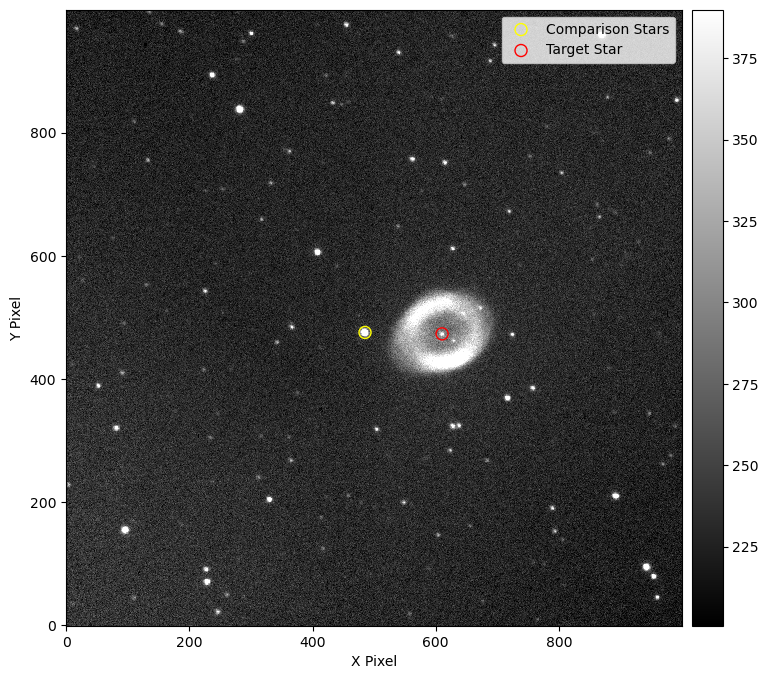

In [112]:
# Load your FITS frame (replace 'your_frame.fits' with the actual file path)
fits_file = '/home/islam/M57/Reduced/V_20240419_0054.fits'
frame_data = fits.getdata(fits_file)

# Extract matched stars' positions (xcenter, ycenter) from the table
comparison_x = matched_table[20]['xcenter']
comparison_y = matched_table[20]['ycenter']

target_x = 610.21314
target_y = 473.28558

# Visualize the frame with matched stars highlighted
plt.figure(figsize=(10, 8))
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(frame_data)  # Scale for better visualization
plots.imshow(image_data, [0.5, 99.7], interpolation='nearest')
plt.scatter(comparison_x, comparison_y, s=75, facecolors='none', edgecolors='yellow', label='Comparison Stars')
plt.scatter(target_x, target_y, s=75, facecolors='none', edgecolors='red' , label='Target Star')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.legend()
plt.grid(False)
plt.savefig('Target and Comparison stars' , format='png')
plt.show()